## Ana

## Analisis Univariado

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [21]:
# 1. Carga del dataset
df = pd.read_csv(r'Data/fake_job_postings.csv')

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   job_id               17880 non-null  int64
 1   title                17880 non-null  str  
 2   location             17534 non-null  str  
 3   department           6333 non-null   str  
 4   salary_range         2868 non-null   str  
 5   company_profile      14572 non-null  str  
 6   description          17879 non-null  str  
 7   requirements         15184 non-null  str  
 8   benefits             10668 non-null  str  
 9   telecommuting        17880 non-null  int64
 10  has_company_logo     17880 non-null  int64
 11  has_questions        17880 non-null  int64
 12  employment_type      14409 non-null  str  
 13  required_experience  10830 non-null  str  
 14  required_education   9775 non-null   str  
 15  industry             12977 non-null  str  
 16  function             11425 non-nu

fraudulent
0    17014
1      866
Name: count, dtype: int64


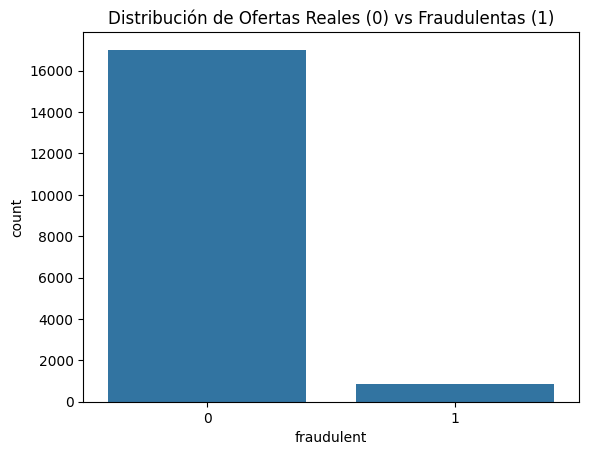

In [23]:
print(df['fraudulent'].value_counts())
sns.countplot(x='fraudulent', data=df)
plt.title('Distribución de Ofertas Reales (0) vs Fraudulentas (1)')
plt.show()

NameError: name 'variables_binarias' is not defined

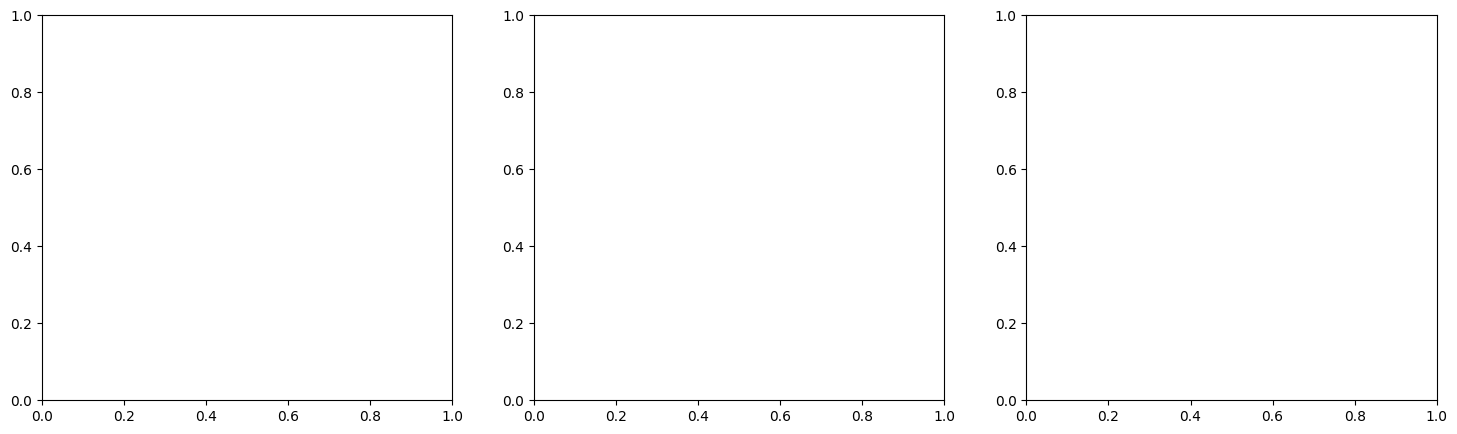

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(variables_binarias):
    sns.countplot(x=col, data=df, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Distribución de {col}', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Cantidad de ofertas')

plt.tight_layout()
plt.show()

required_experience
NaN                 7050
Mid-Senior level    3809
Entry level         2697
Associate           2297
Not Applicable      1116
Director             389
Internship           381
Executive            141
Name: count, dtype: int64


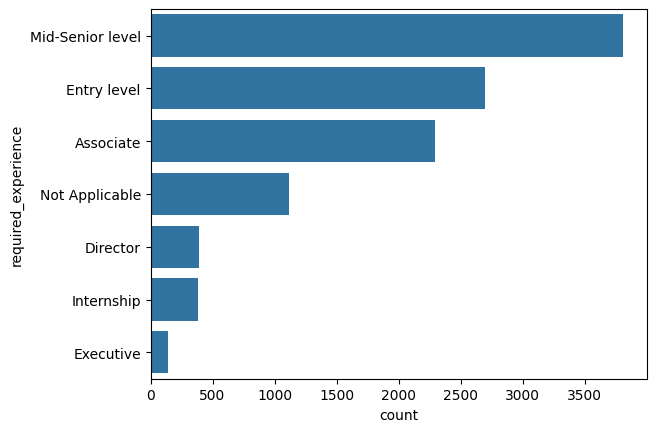

In [ ]:
# Ver los valores únicos de la experiencia
print(df['required_experience'].value_counts(dropna=False))

# Gráfico de barras horizontal por si hay muchas categorías
sns.countplot(y='required_experience', data=df, order=df['required_experience'].value_counts().index)
plt.show()

In [ ]:
#Creamos una columna que rellenamos donde rellenamos nulos con texto vacío, aseguramos que sea string y medimos la longitud

df['description_length'] = df['description'].str.len().fillna(0)



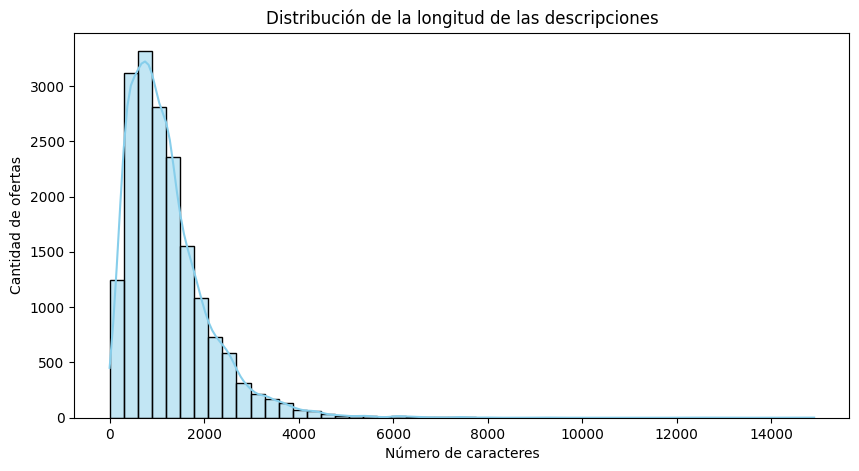

In [ ]:
# 2. Pintamos el histograma
plt.figure(figsize=(10, 5))
sns.histplot(df['description_length'], bins=50, kde=True, color='skyblue')
plt.title('Distribución de la longitud de las descripciones')
plt.xlabel('Número de caracteres')
plt.ylabel('Cantidad de ofertas')
plt.show()

/var/folders/s2/hhmcyygd6hvcg30hhhb4294h0000gn/T/ipykernel_28866/3615561882.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='industry', data=df, order=df['industry'].value_counts().iloc[:10].index, palette='mako')


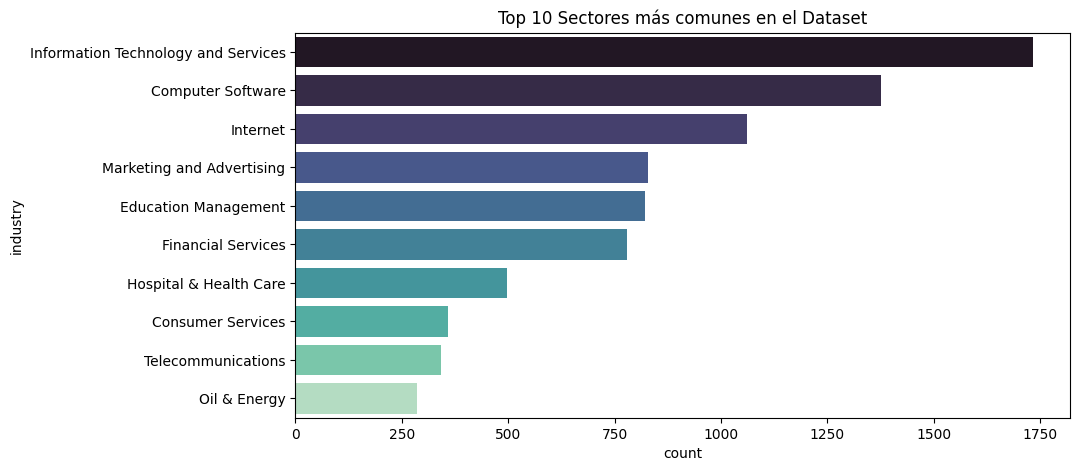

In [ ]:
# Ver los 10 sectores con más ofertas de empleo
plt.figure(figsize=(10, 5))
sns.countplot(y='industry', data=df, order=df['industry'].value_counts().iloc[:10].index, palette='mako')
plt.title('Top 10 Sectores más comunes en el Dataset')
plt.show()

## 📝 Conclusiones del Análisis Univariado

Tras analizar de forma individual las variables clave de nuestro dataset de ofertas de empleo, hemos extraído las siguientes conclusiones fundamentales para el desarrollo del proyecto:

### 1. Desbalanceo Crítico de la Variable Objetivo (`fraudulent`)
* **Hallazgo:** El dataset presenta un desbalanceo masivo. Las ofertas de trabajo fraudulentas representan únicamente alrededor del **5%** del total de los registros, mientras que el 95% restante corresponde a ofertas reales.
* **Impacto en el modelo:** Este desbalanceo nos indica que **no podremos utilizar la métrica de *Accuracy* (Exactitud)** como indicador principal para evaluar nuestros modelos predictivos. Un clasificador básico que prediga siempre "no fraude" obtendría un 95% de acierto pero sería completamente inútil. Deberemos enfocar los esfuerzos en optimizar métricas como el **Recall** (Sensibilidad) y el **F1-Score** para capturar correctamente ese 5% de casos positivos.

### 2. Comportamiento de las Variables Binarias e Indicadores
* **`telecommuting` (Teletrabajo):** La inmensa mayoría de las ofertas publicadas corresponden a puestos presenciales. El trabajo en remoto es una opción muy minoritaria en la distribución general del dataset.
* **`has_company_logo` (Logo de la empresa):** Predominan notablemente las ofertas que sí cuentan con un logotipo de empresa subido a la plataforma, lo que sugiere que la falta de este elemento podría ser una anomalía a investigar.
* **`has_questions` (Preguntas de filtrado):** Existe una distribución bastante equilibrada en el dataset, aunque con una ligera tendencia hacia las ofertas que sí incluyen preguntas de cribado en su formulario de inscripción.

### 3. Distribución Categórica y Concentración de Sectores (`industry`)
* **Hallazgo:** Al analizar el *Top 10* de industrias, el dataset se encuentra fuertemente dominado por el sector de **Tecnología y Servicios de la Información (IT)**, seguido muy de cerca por sectores afines como *Computer Software*, *Internet* y *Financial Services*.
* **Impacto en el modelo:** Al estar la información tan concentrada en perfiles tecnológicos, de desarrollo y oficinas, las dinámicas de fraude que aprenda el modelo estarán estrechamente ligadas al contexto y vocabulario de este sector profesional.

### 4. Características de los Textos Libres (`description_length`)
* **Hallazgo:** La longitud de las descripciones de los puestos sigue una distribución fuertemente asimétrica hacia la derecha (cola larga). Si bien la mayoría de los reclutadores redactan textos extensos y detallados, se detecta un pico anómalo y muy marcado cerca de **0 caracteres** (ofertas que no incluyen apenas texto descriptivo).

### 5. Diagnóstico de Datos Faltantes (Nulos)
* **Hallazgo:** El dataset presenta graves ausencias de información en columnas críticas. La variable `salary_range` (rango salarial) es la que acumula el mayor volumen de nulos con diferencia, seguida por `department`. Otras variables como `required_education` e `industry` también muestran pérdidas notables de datos.


## Analisis Bivariado

In [27]:
import numpy as np

In [28]:
#Filtramos solo columnas numericas(ya que la correlacion solo funciona con numeros)
df_numerico = df.select_dtypes(include=[np.number])

#Calcular matriz de correlacion
matriz_corr = df_numerico.corr()

#Extraer la correlacion de todas las variables con respecto a SalePrice
#Se ordenan de mayor a menos y nos quedamos con las 10 primeras
top_10_variables = matriz_corr["SalePrice"].sort_values(ascending=False).index[:10]

#Dibujar heatmap en base al top 10
plt.figure(figsize=(10, 8))
sns.heatmap(
    df[top_10_variables].corr(), 
    annot=True,          # Añade el número de correlación dentro de cada cuadro
    cmap="coolwarm",     # Escala de color (azul=negativo, rojo=positivo)
    fmt=".2f",           # Limita a 2 decimales
    linewidths=0.5       # Añade una línea fina de separación entre cuadros
)

plt.title("Top 10 Variables Numéricas más Correlacionadas con el Precio", fontsize=14)
plt.show()

KeyError: 'SalePrice'

/var/folders/s2/hhmcyygd6hvcg30hhhb4294h0000gn/T/ipykernel_15612/1443413237.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='has_company_logo', y='fraudulent', data=df, palette='coolwarm', errorbar=None)


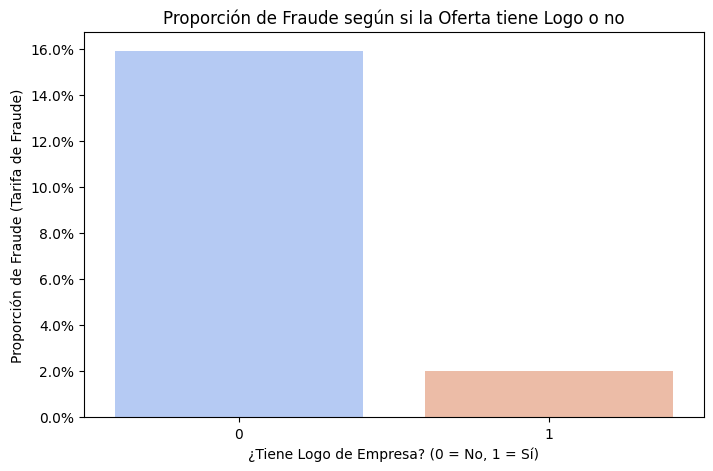

In [ ]:
plt.figure(figsize=(8, 5))
# Al calcular la media de una variable 0/1, obtenemos directamente la proporción de fraude (de 0 a 1)
sns.barplot(x='has_company_logo', y='fraudulent', data=df, palette='coolwarm', errorbar=None)
plt.title('Proporción de Fraude según si la Oferta tiene Logo o no')
plt.ylabel('Proporción de Fraude (Tarifa de Fraude)')
plt.xlabel('¿Tiene Logo de Empresa? (0 = No, 1 = Sí)')

# Convertir el eje Y a porcentaje para que el profesor lo entienda mejor
from matplotlib.ticker import PercentFormatter
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.show()

/var/folders/s2/hhmcyygd6hvcg30hhhb4294h0000gn/T/ipykernel_15612/987795071.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='has_questions', y='fraudulent', data=df, palette='coolwarm', errorbar=None)


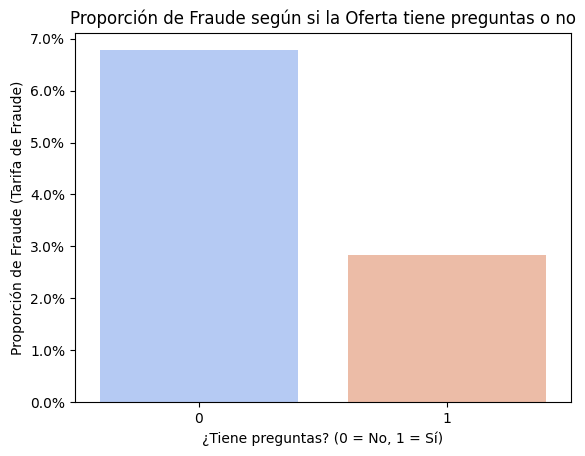

In [ ]:
sns.barplot(x='has_questions', y='fraudulent', data=df, palette='coolwarm', errorbar=None)
plt.title('Proporción de Fraude según si la Oferta tiene preguntas o no')
plt.ylabel('Proporción de Fraude (Tarifa de Fraude)')
plt.xlabel('¿Tiene preguntas? (0 = No, 1 = Sí)')

# Convertir el eje Y a porcentaje para que el profesor lo entienda mejor
from matplotlib.ticker import PercentFormatter
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.show()

In [25]:
plt.figure(figsize=(10, 5))
# Comparamos la distribución de longitudes para ofertas reales (0) y falsas (1)
sns.boxplot(x='fraudulent', y='description_length', data=df, palette='Set2')
plt.title('Comparación de la Longitud de la Descripción: Reales vs Fraudes')
plt.xlabel('¿Es Fraude? (0 = No, 1 = Sí)')
plt.ylabel('Longitud del texto (caracteres)')
plt.show()

ValueError: Could not interpret value `description_length` for `y`. An entry with this name does not appear in `data`.

<Figure size 1000x500 with 0 Axes>

/var/folders/s2/hhmcyygd6hvcg30hhhb4294h0000gn/T/ipykernel_15612/2309985699.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=industrias_top['mean'], y=industrias_top.index, palette='Reds_r')


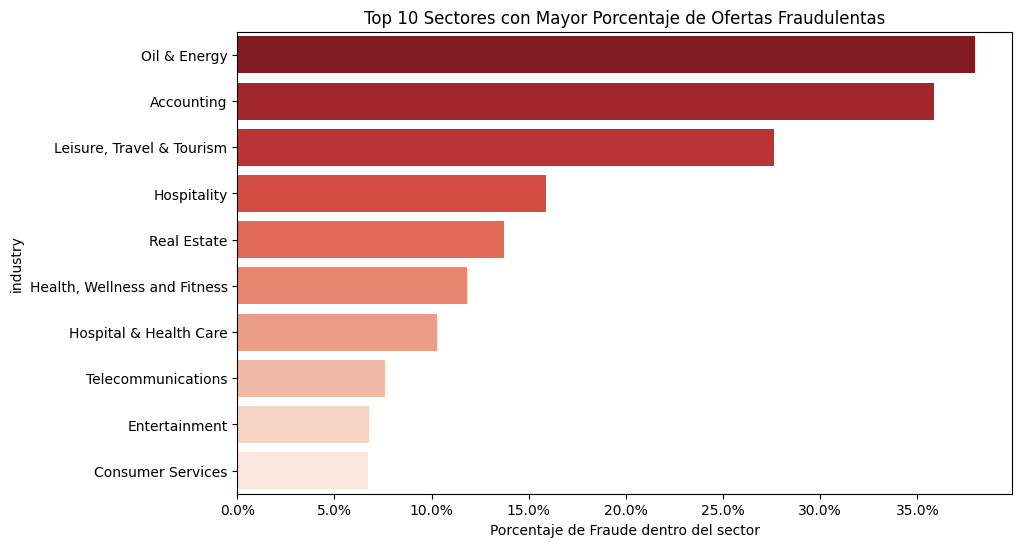

In [26]:
# 1. Agrupamos por industria y calculamos el porcentaje de fraude y el conteo total
analisis_industria = df.groupby('industry')['fraudulent'].agg(['mean', 'count'])

# 2. Filtramos industrias con muy pocas ofertas (por ejemplo, menos de 50) para evitar datos ruidosos
industrias_top = analisis_industria[analisis_industria['count'] > 50].sort_values(by='mean', ascending=False).head(10)

# 3. Pintamos el Top 10 de sectores más peligrosos
plt.figure(figsize=(10, 6))
sns.barplot(x=industrias_top['mean'], y=industrias_top.index, palette='Reds_r')
plt.title('Top 10 Sectores con Mayor Porcentaje de Ofertas Fraudulentas')
plt.xlabel('Porcentaje de Fraude dentro del sector')
plt.gca().xaxis.set_major_formatter(PercentFormatter(1.0))
plt.show()